In [8]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

In [172]:
import seaborn as sns

In [9]:
# First step: Construct the Hamiltonian of Kitaev chain (1d superconductor)
# Second step: Obtain the data (Parameters, Energy gap)
# Third step: Data analysis 

In [10]:
#Building the BdG Hamiltonian

def kitaev_bdg(N,mu,t,Delta):
    A = np.zeros((N,N))
    B = np.zeros((N,N))

    for i in range(N):
        A[i,i] = -mu
        if i<N-1:
            A[i,i+1] = -t
            A[i+1,i] = -t

            B[i,i+1] = Delta
            B[i+1,i] = -Delta

    H = np.block([[A,B],[B,-A]])
    return H


In [12]:
kitaev_bdg(5,1,1,1)

array([[-1., -1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.],
       [-1., -1., -1.,  0.,  0., -1.,  0.,  1.,  0.,  0.],
       [ 0., -1., -1., -1.,  0.,  0., -1.,  0.,  1.,  0.],
       [ 0.,  0., -1., -1., -1.,  0.,  0., -1.,  0.,  1.],
       [ 0.,  0.,  0., -1., -1.,  0.,  0.,  0., -1.,  0.],
       [ 0.,  1.,  0.,  0.,  0.,  1.,  1., -0., -0., -0.],
       [-1.,  0.,  1.,  0.,  0.,  1.,  1.,  1., -0., -0.],
       [ 0., -1.,  0.,  1.,  0., -0.,  1.,  1.,  1., -0.],
       [ 0.,  0., -1.,  0.,  1., -0., -0.,  1.,  1.,  1.],
       [ 0.,  0.,  0., -1.,  0., -0., -0., -0.,  1.,  1.]])

In [22]:
#Diagonalizar

H = kitaev_bdg(N=100,mu = 1.0, t =1.0, Delta = 1.0)

eigvals = np.linalg.eigvalsh(H)

print(eigvals[0:10])

[-2.9996732  -2.99869292 -2.99705947 -2.99477339 -2.9918354  -2.98824648
 -2.98400777 -2.97912067 -2.97358676 -2.96740786]


In [110]:
#Calculating the energy gap

np.size(eigvals)

eigvals = eigvals[eigvals>1e-40]

gap = np.min(eigvals)

In [111]:
#Searching for gap position in list

print(gap)

for i in range(200):
    if eigvals[i] == gap:
        print(i)
        break

4.440892098500626e-16
99


In [117]:
#Generating date for mu and gap

dados = []
mus = np.linspace(-4,4,200)

for mu in mus:
    eigval = np.linalg.eigvalsh(kitaev_bdg(100,mu,1,1))
    eigval = eigval[eigval>1e-40]
    e_gap = np.min(eigval)
    dados.append([mu,e_gap])

In [118]:
#Criando Data Frame

df = pd.DataFrame(dados,columns = ["mu","gap"])

print(df.head())

         mu       gap
0 -4.000000  2.001896
1 -3.959799  1.961714
2 -3.919598  1.921532
3 -3.879397  1.881352
4 -3.839196  1.841172


In [119]:
#Média dos valores

mean_gap = df["gap"].mean()
mean_mu = df["mu"].mean()

print(mean_gap)
print(mean_mu)

0.5964163873091648
1.4210854715202004e-16


In [120]:
#Valor mais próximo da média

gap_close_mean = df["gap"].iloc[0]-mean_gap
closest = 0

for i in range(199):
    if abs(df["gap"].iloc[i+1]-mean_gap) < gap_close_mean:
        gap_close_mean = df["gap"].iloc[i+1]-mean_gap
        closest = i+1

print('closest is at position', closest, 'the value is', df["gap"].iloc[i+1])

closest is at position 35 the value is 2.0018962574428127


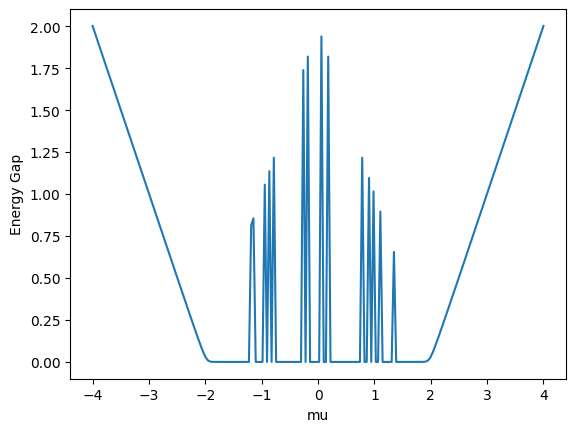

In [121]:
#Plotar gráfico gap x mu

plt.plot(df["mu"],df["gap"])
plt.xlabel("mu")
plt.ylabel("Energy Gap")
plt.show()

In [122]:
df["gap"].iloc[100]

np.float64(1.3322673037157788e-15)

In [129]:
#Generating dataset for mu, Delta and energy

dados = []

mu = np.linspace(-4,4,100)
deltas = np.linspace(0.2,2.0,20)

for mu in mus:
    for delta in deltas:
        eigenvals = np.linalg.eigvalsh(kitaev_bdg(100,mu,1,delta))
        positive = eigenvals[eigenvals>1e-20]
        gap = np.min(positive)
        dados.append([mu,delta,gap])

df = pd.DataFrame(dados, columns = ["mu","Delta","Gap"])

In [130]:
print(df.head())

    mu     Delta       Gap
0 -4.0  0.200000  2.001005
1 -4.0  0.294737  2.001049
2 -4.0  0.389474  2.001110
3 -4.0  0.484211  2.001187
4 -4.0  0.578947  2.001281


In [132]:
#Saving data as a csv

df.to_csv("kitaev_gap_dataset.csv",index = False)

In [134]:
kitaev_data = pd.read_csv("kitaev_gap_dataset.csv")

In [143]:
#Média para cada valor de delta usando groupby

kitaev_data.groupby("Delta")["Gap"].mean()

kitaev_data.groupby("Delta").agg({"Gap":["mean","std","max"]})

Gap                    
              mean       std       max
Delta                                 
0.200000  0.508120  0.654584  2.001005
0.294737  0.508237  0.654559  2.001049
0.389474  0.575287  0.631891  2.001110
0.484211  0.607929  0.631762  2.001187
0.578947  0.631260  0.641152  2.001281
0.673684  0.599523  0.654650  2.001391
0.768421  0.593720  0.655214  2.001518
0.863158  0.642203  0.667269  2.001661
0.957895  0.637218  0.679169  2.001820
1.052632  0.641227  0.674850  2.001996
1.147368  0.622291  0.678728  2.002186
1.242105  0.646117  0.689912  2.002393
1.336842  0.605065  0.674188  2.002616
1.431579  0.622725  0.682979  2.002853
1.526316  0.617227  0.688097  2.003106
1.621053  0.603523  0.684466  2.003375
1.715789  0.597936  0.684649  2.003658
1.810526  0.622874  0.683587  2.003957
1.905263  0.628347  0.698266  2.004270
2.000000  0.614303  0.695102  2.004598

In [165]:
#Criando coluna de fase

kitaev_data["phase"] = np.where(np.abs(kitaev_data["mu"])<2, "topologial", "trivial")

print(kitaev_data.head())

    mu     Delta       Gap    phase
0 -4.0  0.200000  2.001005  trivial
1 -4.0  0.294737  2.001049  trivial
2 -4.0  0.389474  2.001110  trivial
3 -4.0  0.484211  2.001187  trivial
4 -4.0  0.578947  2.001281  trivial


In [167]:
kitaev_data.groupby("phase").mean()

,mu,Delta,Gap
phase,,,
topologial,4.529710e-17,1.1,0.191945
trivial,4.884981e-17,1.1,1.020568


Text(0, 0.5, 'Gap')

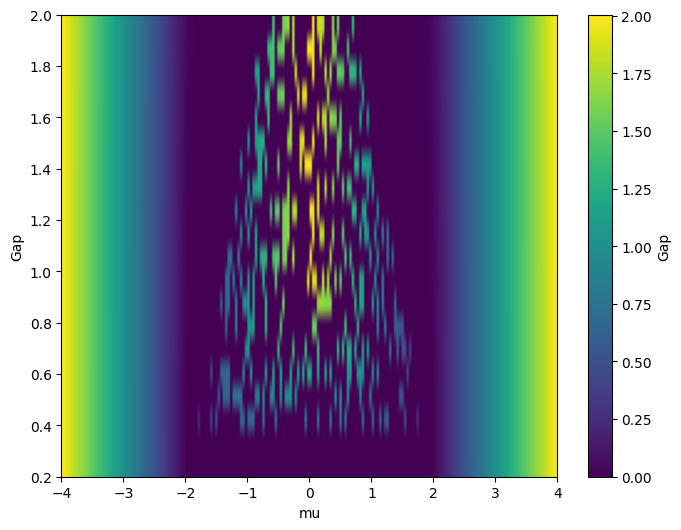

In [170]:
#Construindo o mapa de calor

heatmap = kitaev_data.pivot( index = "Delta", columns = "mu", values = "Gap")

plt.figure(figsize= (8,6))

plt.imshow(heatmap, aspect = "auto", origin = "lower", extent = [kitaev_data["mu"].min(), kitaev_data["mu"].max(), kitaev_data["Delta"].min(), kitaev_data["Delta"].max()])
plt.colorbar(label = "Gap")
plt.xlabel("mu")
plt.ylabel("Gap")

<Axes: xlabel='mu', ylabel='Delta'>

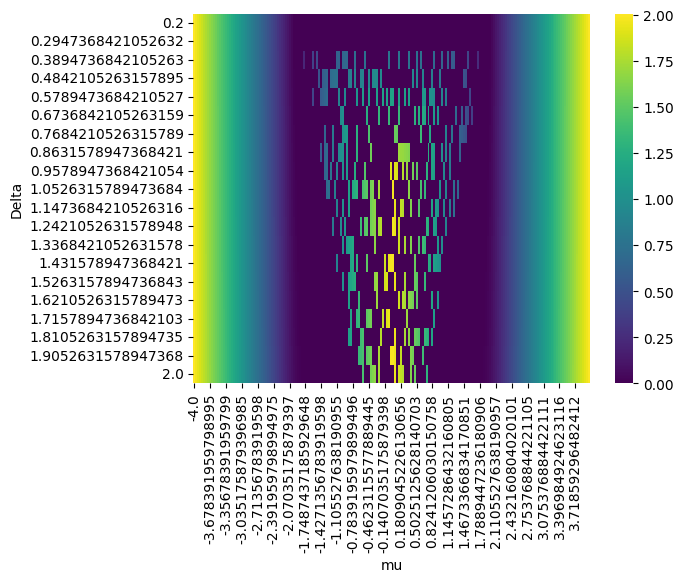

In [177]:
sns.heatmap(heatmap,cmap = "viridis",fmt = ".2e")